In [1]:
import category_encoders as ce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    precision_recall_curve,
)
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [2]:
train_csv = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_csv = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

# コピーの作成
train = train_csv.copy()
test = test_csv.copy()

print("--- Train Info ---")
print(train.info())
print("\n--- Test Info ---")
print(test.info())

print("\n--- Train Head ---")
display(train.head())

--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Test Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passeng

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## データの概観・前処理

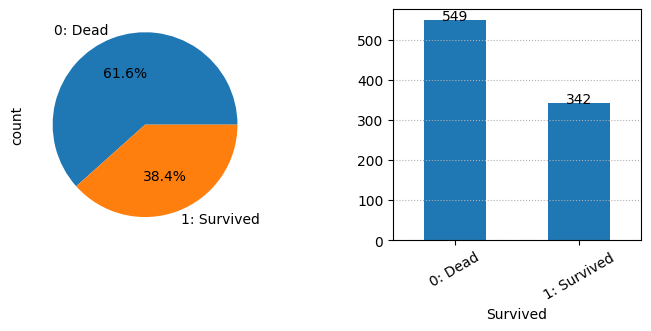

In [3]:
DICT_SURVIVED = {0: '0: Dead', 1: '1: Survived'}


def arrange_bar(ax, sr):
    ax.set_xticklabels(
        labels=ax.get_xticklabels(), rotation=30, horizontalalignment="center"
    )
    ax.grid(axis='y', linestyle='dotted')
    [
        ax.text(i, count, count, horizontalalignment='center')
        for i, count in enumerate(sr)
    ]


sr_survived = train['Survived'].value_counts().rename(index=DICT_SURVIVED)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
fig.subplots_adjust(wspace=0.5, hspace=0.5)
sr_survived.plot.pie(autopct="%1.1f%%", ax=axes[0])
sr_survived.plot.bar(ax=axes[1])
arrange_bar(axes[1], sr_survived)
plt.show()

In [4]:
def arrange_stack_bar(ax):
    ax.set_xticklabels(
        labels=ax.get_xticklabels(), rotation=30, horizontalalignment="center"
    )
    ax.grid(axis='y', linestyle='dotted')


def output_bars(df, column, index={}):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    if len(index) == 0:
        df_vc = (
            df.groupby([column])["Survived"]
            .value_counts(sort=False)
            .unstack()
            .rename(columns=DICT_SURVIVED)
        )
        df[column].value_counts().plot.pie(ax=axes[0, 0], autopct="%1.1f%%")
        (
            df.groupby([column])["Survived"]
            .value_counts(sort=False, normalize=True)
            .unstack()
            .rename(columns=DICT_SURVIVED)
            .plot.bar(ax=axes[1, 1], stacked=True)
        )
    else:
        df_vc = (
            df.groupby([column])["Survived"]
            .value_counts(sort=False)
            .unstack()
            .rename(index=index, columns=DICT_SURVIVED)
        )
        df[column].value_counts().rename(index).plot.pie(
            ax=axes[0, 0], autopct="%1.1f%%"
        )
        (
            df.groupby([column])["Survived"]
            .value_counts(sort=False, normalize=True)
            .unstack()
            .rename(index=index, columns=DICT_SURVIVED)
            .plot.bar(ax=axes[1, 1], stacked=True)
        )

    df_vc.plot.bar(ax=axes[1, 0])
    for rect in axes[1, 0].patches:
        height = rect.get_height()
        if not np.isnan(height):
            axes[1, 0].annotate(
                '{:.0f}'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
            )

    df_vc.plot.bar(ax=axes[0, 1], stacked=True)
    arrange_stack_bar(axes[0, 1])
    arrange_stack_bar(axes[1, 0])
    arrange_stack_bar(axes[1, 1])

    [
        axes[0, 1].text(i, item.sum(), item.sum(), horizontalalignment='center')
        for i, (_, item) in enumerate(df_vc.iterrows())
    ]
    plt.show()

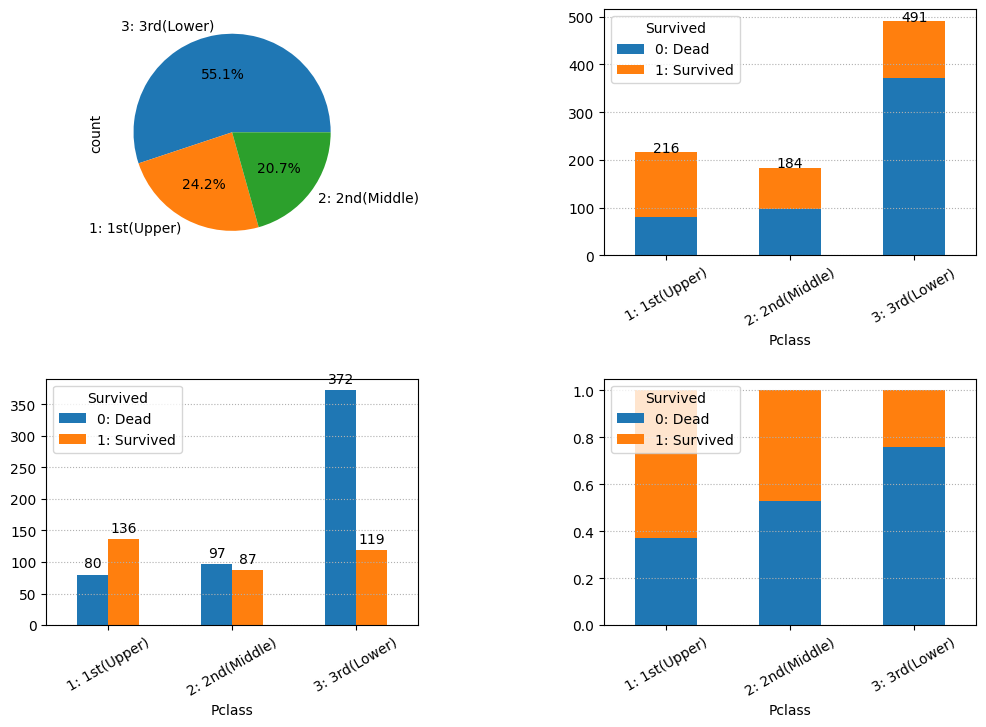

In [5]:
# Pclass (席等級)
DICT_PCLASS = {1: '1: 1st(Upper)', 2: '2: 2nd(Middle)', 3: '3: 3rd(Lower)'}
output_bars(train, 'Pclass', DICT_PCLASS)

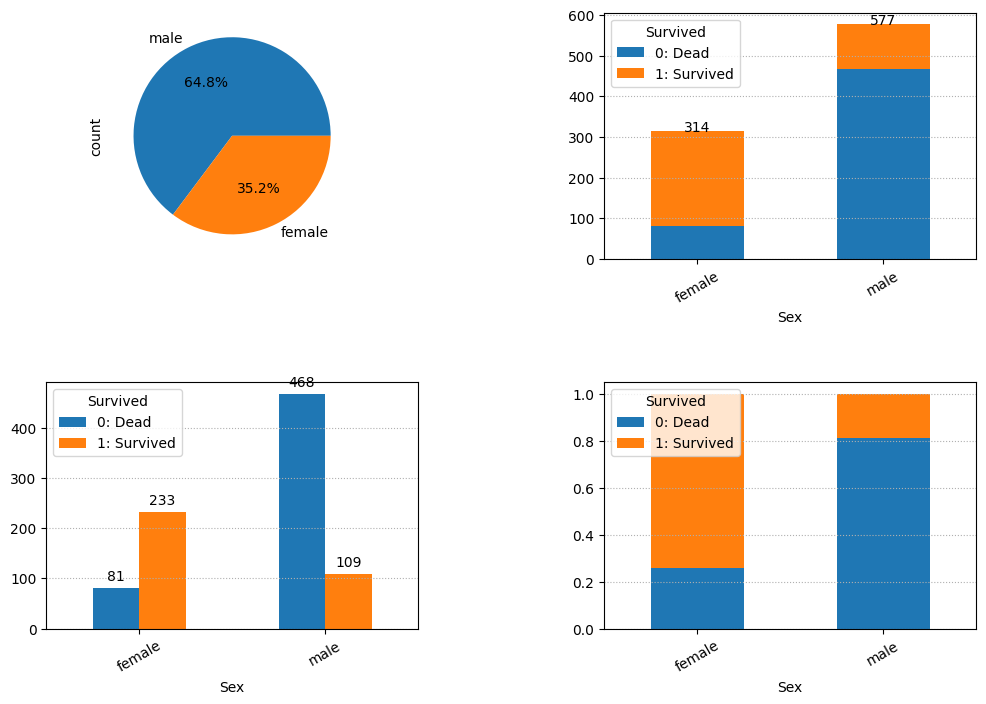

In [6]:
# Sex (性別)
output_bars(train, 'Sex')

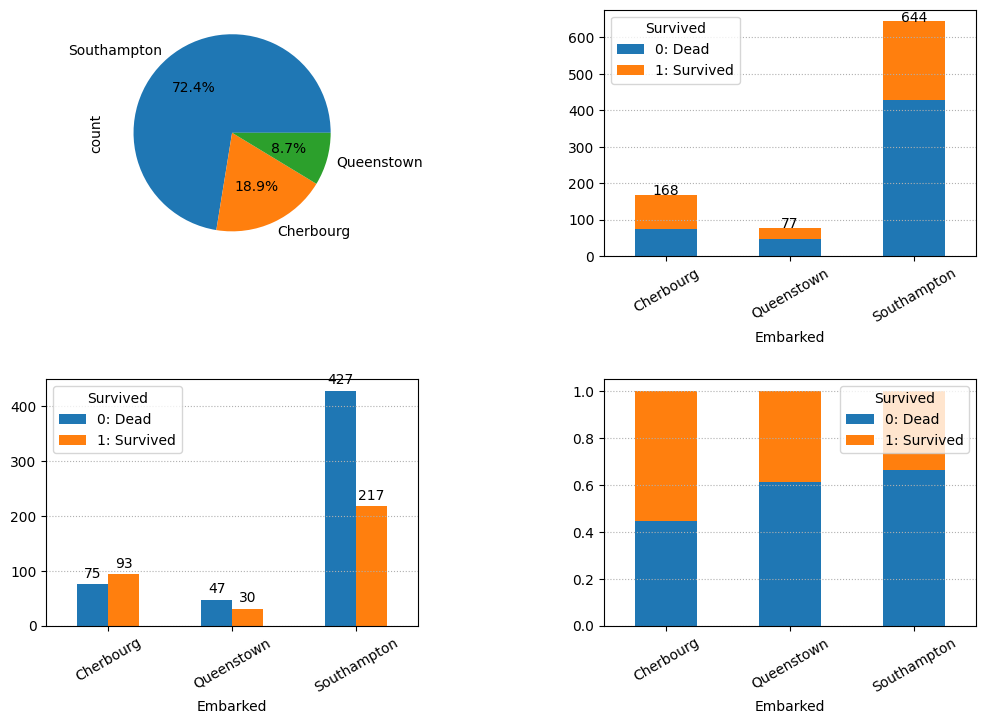

In [7]:
# Embarked (乗船港)
DICT_EMBARK = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
output_bars(train, 'Embarked', DICT_EMBARK)

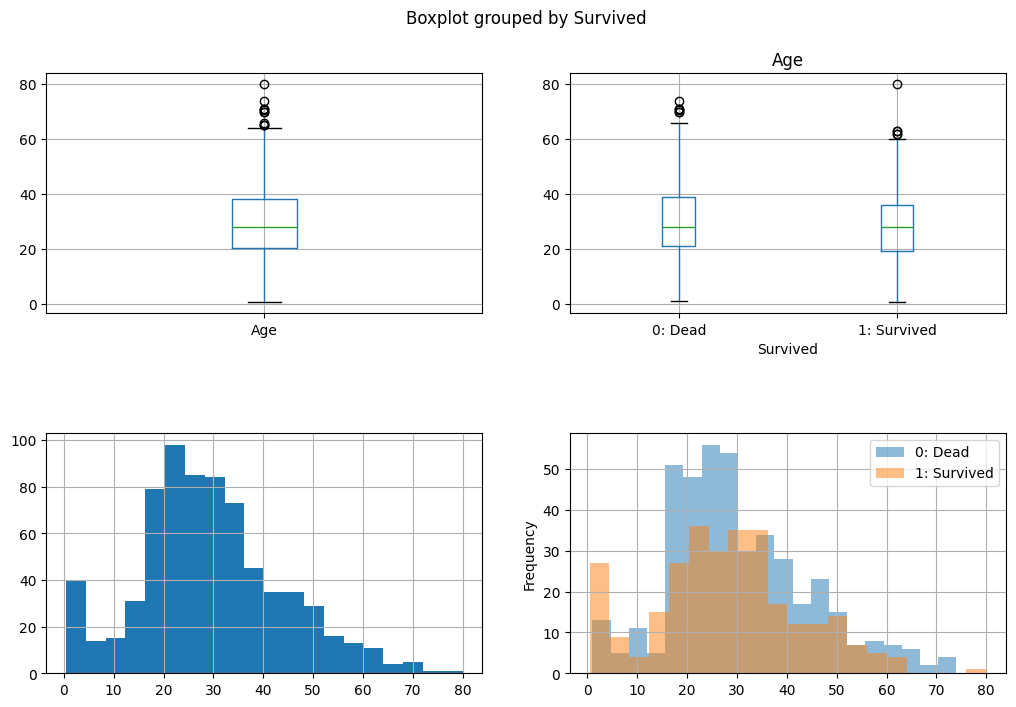

In [8]:
# 欠損値の扱い: 除去されている
def output_box_hist(column, bins=20, query=None):
    if query == None:
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    else:
        fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
        train_csv.query(query)[column].hist(ax=axes[2, 0], bins=bins)
        train_csv.query(query).groupby('Survived')[column].plot.hist(
        ax=axes[2, 1], bins=bins, alpha=0.5, legend=True, grid=True)
        axes[2, 1].legend(labels=[DICT_SURVIVED[int(float((text.get_text())))] for text in axes[2, 1].get_legend().get_texts()])

    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    train_csv.boxplot(ax=axes[0, 0], column=[column])
    train_csv.boxplot(ax=axes[0, 1], column=[column], by='Survived')
    axes[0, 1].set_xticklabels([DICT_SURVIVED[int(float(xticklabel.get_text()))] for xticklabel in axes[0, 1].get_xticklabels()])
    train_csv[column].hist(ax=axes[1, 0], bins=bins)
    train_csv.groupby('Survived')[column].plot.hist(ax=axes[1, 1], bins=bins, alpha=0.5, grid=True, legend=True)
    axes[1, 1].legend(labels=[DICT_SURVIVED[int(float((text.get_text())))] for text in axes[1, 1].get_legend().get_texts()])

    plt.show()

output_box_hist('Age')


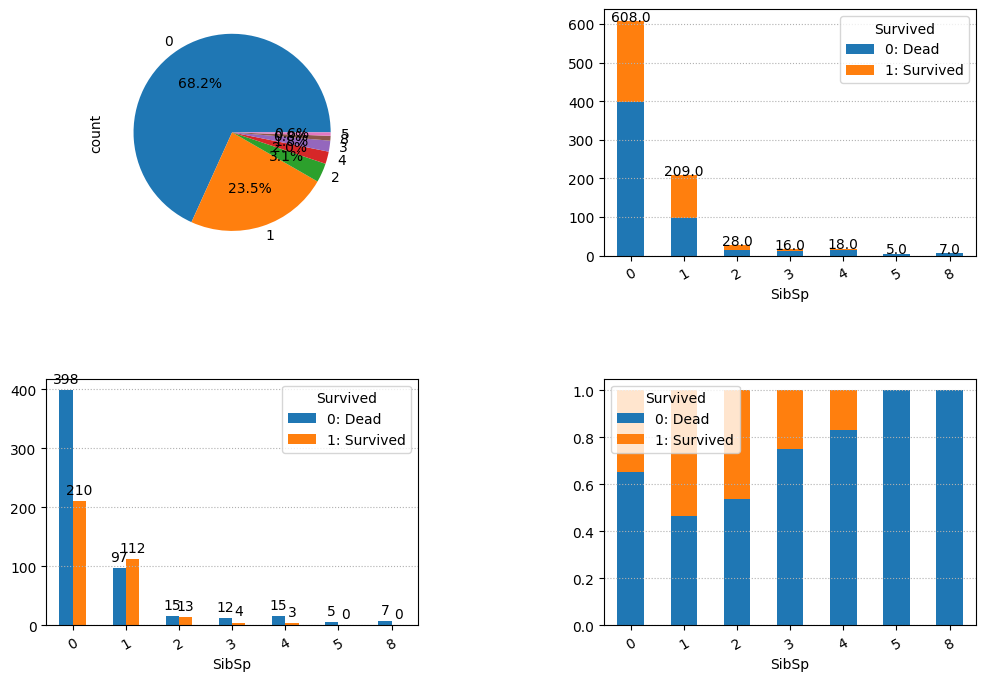

In [9]:
output_bars(train_csv, 'SibSp')

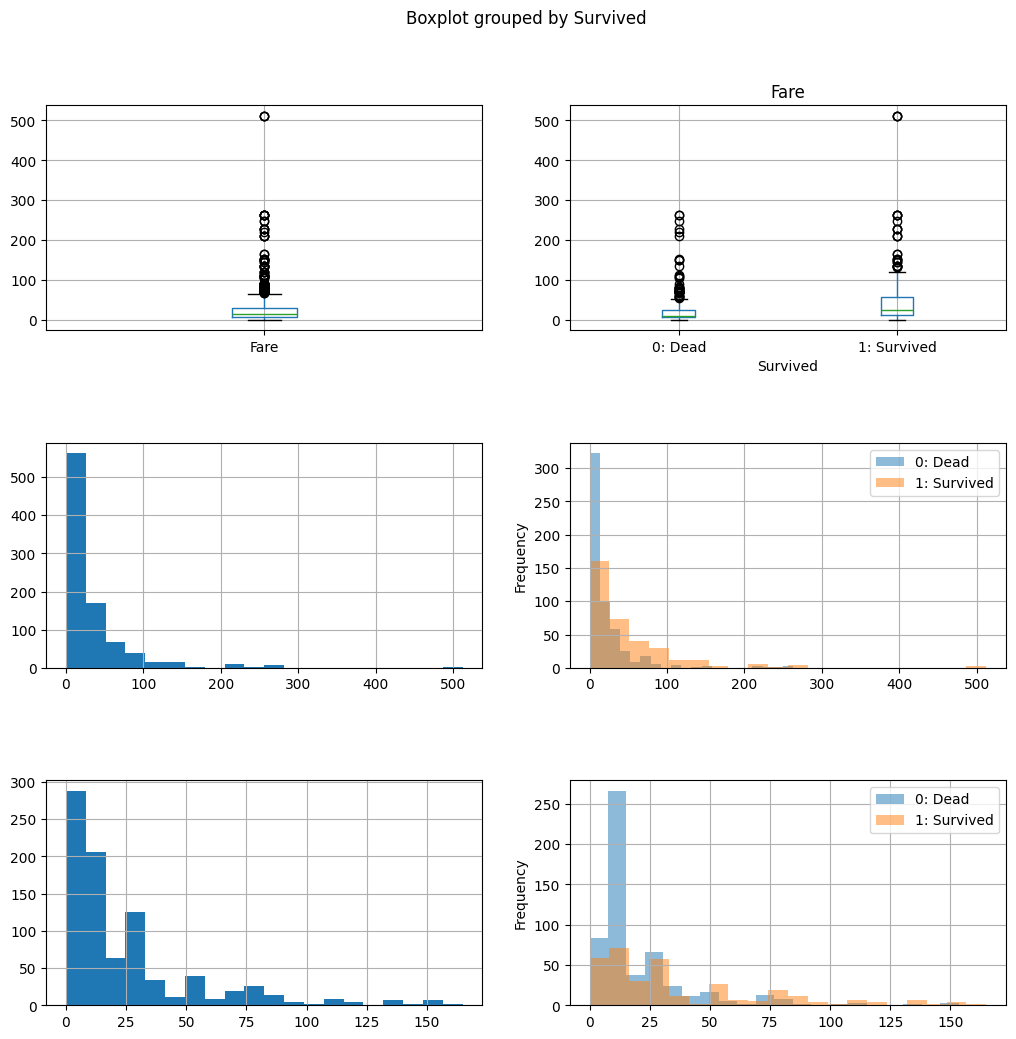

In [10]:
output_box_hist('Fare', 20, 'Fare < 200')

In [11]:
train_csv.loc[:, ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr().style.background_gradient(axis=None)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [12]:
both = pd.concat([train_csv, test_csv], ignore_index=True)

In [13]:
# Fareの欠損値を補完(Pclassごとの中央値で補完)
both['Fare'] = both.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# Last Name作成
both['Last_Name'] = both['Name'].apply(lambda x: str.split(x, ",")[0])

# Fareを文字列化してLast_Nameと結合(グルーピング用のキー作成)
both['Name_Fare'] = both['Last_Name'] + both['Fare'].astype('str')


In [14]:
# 姓とFareでグルーピング
def process_name(i, name_fare):
    tickets = both.loc[(both['Name_Fare'] == name_fare) & (both['Group'].isnull()),'Ticket'].unique().tolist()
    both.loc[(both['Name_Fare'] == name_fare) & (both['Group'].isnull()), 'Group'] = i
    for ticket in tickets:
        process_ticket(i, ticket)

# チケットでグルーピング        
def process_ticket(i, ticket):
    name_fares = both.loc[(both['Ticket'] == ticket) & (both['Group'].isnull()),'Name_Fare'].unique().tolist()
    both.loc[(both['Ticket'] == ticket) & (both['Group'].isnull()), 'Group'] = i
    for name_fare in name_fares:
        process_name(i, name_fare)

both['Group'] = None

# チケットでグルーピング(再帰処理で姓とFare、チケットでのグルーピングを繰り返す)
[process_ticket(i, ticket) for i, ticket in enumerate(both['Ticket'].unique().tolist())]

print('Ticket Count', both['Ticket'].nunique())
print('Name & Fare Count', both['Name_Fare'].nunique())
print('Ticket & Name Count', both['Group'].nunique())

Ticket Count 929
Name & Fare Count 982
Ticket & Name Count 887


In [15]:
titles = ["Mr.", "Miss.", "Mrs.", "Master.", "Dr.", "Rev.", "Col.", "Ms.", 
          "Mlle.", "Mme.", "Capt.", "Countess.", "Major.", "Jonkheer.", "Don.", 
         "Dona.", "Sir.", "Lady."]

# Titleを抽出
for title in titles:
    both.loc[both.Name.str.contains(title, regex=False), 'Title'] = title
    
print(both.loc[:,['Name', 'Title']])

                                                   Name    Title
0                               Braund, Mr. Owen Harris      Mr.
1     Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs.
2                                Heikkinen, Miss. Laina    Miss.
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs.
4                              Allen, Mr. William Henry      Mr.
...                                                 ...      ...
1304                                 Spector, Mr. Woolf      Mr.
1305                       Oliva y Ocana, Dona. Fermina    Dona.
1306                       Saether, Mr. Simon Sivertsen      Mr.
1307                                Ware, Mr. Frederick      Mr.
1308                           Peter, Master. Michael J  Master.

[1309 rows x 2 columns]


In [16]:
both.loc[both['Title']=='Master.', 'NewTitle'] = 'Master'
both.loc[(both['Sex']=='male')&(both['NewTitle']!='Master'), 'NewTitle'] = 'Mr'
both.loc[(both['Title']=='Mlle.')|((both['Title']=='Ms.')|(both['Title']=='Miss.')), 'NewTitle'] = 'Miss'
both.loc[(both['Sex']=='female')&(both['NewTitle']!='Miss'), 'NewTitle'] = 'Mrs'

### Age の欠損値補完
Pclass と NewTitle(敬称)の組み合わせごとの中央値で補完する。年齢分布は敬称(Mr/Miss/Mrs/Master)ごとに大きく異なるため、単純な全体中央値より精度良く補完できる。


In [17]:
# Pclass × NewTitle ごとの中央値でAgeの欠損値を補完
both['Age'] = both.groupby(['Pclass', 'NewTitle'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 上記の組み合わせでも中央値が取れない場合のフォールバック
both['Age'] = both['Age'].fillna(both['Age'].median())

print('Age欠損数(補完後):', both['Age'].isnull().sum())


Age欠損数(補完後): 0


In [18]:
both['FamilySize'] = both['SibSp'] + both['Parch']

In [19]:
COPIED = ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'FamilySize', 'Embarked', 'Group', 'NewTitle']
train = both.loc[:890, COPIED].copy()
test = both.loc[891:, COPIED].copy()


In [20]:
# 学習データの最頻値を取得
most_frequent_embarked = train['Embarked'].mode()[0]

# 欠損値を補完
train['Embarked'] = train['Embarked'].fillna(most_frequent_embarked)
test['Embarked'] = test['Embarked'].fillna(most_frequent_embarked)

In [21]:
# sparse=False -> sparse_output=False に変更
oh_encoder = OneHotEncoder(sparse_output=False, drop='first')

# 学習データで fit と transform を実行
features = ['Embarked', 'NewTitle']
oh_encoder.fit(train[features])

# get_feature_names() -> get_feature_names_out() に変更
encoded_cols = oh_encoder.get_feature_names_out(features)

# train の変換
onehot_train = pd.DataFrame(
    oh_encoder.transform(train[features]),
    columns=encoded_cols,
    index=train.index,
    dtype=np.int8,
)
train = pd.concat([train, onehot_train], axis=1)

# test の変換
onehot_test = pd.DataFrame(
    oh_encoder.transform(test[features]),
    columns=encoded_cols,
    index=test.index,
    dtype=np.int8,
)
test = pd.concat([test, onehot_test], axis=1)

In [22]:
import category_encoders as ce

# CountEncoder の定義 (cols に列名をリストで指定)
count_encoder = ce.CountEncoder(cols=['Group'])

# train[["Group"]] のように DataFrame として渡します
train['Group_Count'] = count_encoder.fit_transform(train[['Group']])

# test の変換
test['Group_Count'] = count_encoder.transform(test[['Group']])

# コメントの「+1」処理を入れる場合
test['Group_Count'] = test['Group_Count'].astype(int) + 1

In [23]:
# 1. LeaveOneOutEncoder の実行 (DataFrame として渡す)
te = ce.LeaveOneOutEncoder(cols=['Group'])
train['Group_Target'] = te.fit_transform(train[['Group']], train['Survived'])
test['Group_Target'] = te.transform(test[['Group']])

# 2. Group_Count == 2 のグループの Target 値を train の生存率平均で更新
# for ループを回さず、Pandasの map 処理で行う方が安全・高速です
group_survived_mean = train.groupby('Group')['Survived'].mean()

# Group_Count == 2 に該当する行の Group_Target を置き換え
mask_count_2 = test['Group_Count'] == 2
test.loc[mask_count_2, 'Group_Target'] = test.loc[mask_count_2, 'Group'].map(
    group_survived_mean
)

# 3. 未登場（Group_Count == 0）の補完
test.loc[test['Group_Count'] == 0, 'Group_Target'] = 0.384

In [24]:
oe = OrdinalEncoder()

# fit_transform の結果（NumPy配列）を新しい列として直接割り当て
cols_in = ['Pclass', 'Sex']
cols_out = ['PclassEncoded', 'SexEncoded']

# 整数型（int）に変換して代入
train[cols_out] = oe.fit_transform(train[cols_in]).astype(int)
test[cols_out] = oe.transform(test[cols_in]).astype(int)

In [25]:
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    float64
 2   Pclass         891 non-null    int64  
 3   Sex            891 non-null    object 
 4   Age            891 non-null    float64
 5   FamilySize     891 non-null    int64  
 6   Embarked       891 non-null    object 
 7   Group          891 non-null    object 
 8   NewTitle       891 non-null    object 
 9   Embarked_Q     891 non-null    int8   
 10  Embarked_S     891 non-null    int8   
 11  NewTitle_Miss  891 non-null    int8   
 12  NewTitle_Mr    891 non-null    int8   
 13  NewTitle_Mrs   891 non-null    int8   
 14  Group_Count    891 non-null    int64  
 15  Group_Target   891 non-null    float64
 16  PclassEncoded  891 non-null    int64  
 17  SexEncoded     891 non-null    int64  
dtypes: float64

In [26]:
# 数値列のみを対象にして相関行列を計算し、グラデーションを表示
train.iloc[:, 1:].corr(numeric_only=True).style.background_gradient(axis=None)

,Survived,Pclass,Age,FamilySize,Embarked_Q,Embarked_S,NewTitle_Miss,NewTitle_Mr,NewTitle_Mrs,Group_Count,Group_Target,PclassEncoded,SexEncoded
Survived,1.000000,-0.338481,-0.059187,0.016639,0.003650,-0.149683,0.335636,-0.566512,0.350782,0.022062,0.341335,-0.338481,-0.543351
Pclass,-0.338481,1.000000,-0.421771,0.065997,0.221009,0.074053,-0.010261,0.094035,-0.167243,0.021406,-0.329771,1.000000,0.131900
Age,-0.059187,-0.421771,1.000000,-0.275358,-0.107777,0.023288,-0.303227,0.264458,0.212431,-0.243061,0.081368,-0.421771,0.100984
FamilySize,0.016639,0.065997,-0.275358,1.000000,-0.058592,0.077359,0.107500,-0.353832,0.148952,0.744244,-0.091530,0.065997,-0.200988
Embarked_Q,0.003650,0.221009,-0.107777,-0.058592,1.000000,-0.499421,0.167531,-0.076789,-0.092493,-0.064677,-0.030181,0.221009,-0.074115
Embarked_S,-0.149683,0.074053,0.023288,0.077359,-0.499421,1.000000,-0.137144,0.106125,-0.003776,0.071349,-0.134892,0.074053,0.119224
NewTitle_Miss,0.335636,-0.010261,-0.303227,0.107500,0.167531,-0.137144,1.000000,-0.630477,-0.210621,0.112982,0.040707,-0.010261,-0.693916
NewTitle_Mr,-0.566512,0.094035,0.264458,-0.353832,-0.076789,0.106125,-0.630477,1.000000,-0.506761,-0.279150,-0.069447,0.094035,0.908578
NewTitle_Mrs,0.350782,-0.167243,0.212431,0.148952,-0.092493,-0.003776,-0.210621,-0.506761,1.000000,0.077318,0.047336,-0.167243,-0.557751
Group_Count,0.022062,0.021406,-0.243061,0.744244,-0.064677,0.071349,0.112982,-0.279150,0.077318,1.000000,-0.049503,0.021406,-0.152879


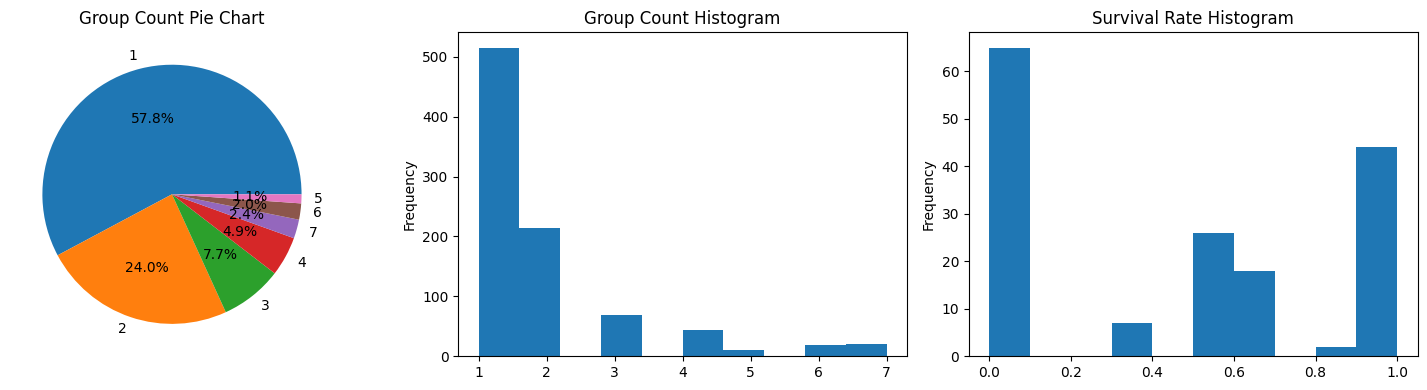

In [27]:
_, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# 1. 円グラフ: Y軸ラベル（Group_Count）を消して見やすく調整
train['Group_Count'].value_counts().plot.pie(
    ax=axes[0],
    title='Group Count Pie Chart',
    autopct='%1.1f%%',
    ylabel='',  # 円グラフ横の余分なラベルを消去
)

# 2. ヒストグラム1
train['Group_Count'].plot.hist(ax=axes[1], title='Group Count Histogram')

# 3. ヒストグラム2
train.query('Group_Count > 2')['Group_Target'].plot.hist(
    ax=axes[2], title='Survival Rate Histogram'
)

plt.tight_layout()  # タイトルや軸ラベルの重なりを自動調整
plt.show()

/tmp/ipykernel_16/1027136879.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  train.query('Group_Count > 2').Group_Target.hist(ax=ax, by=train['Group_Count'], range=(0, 1))


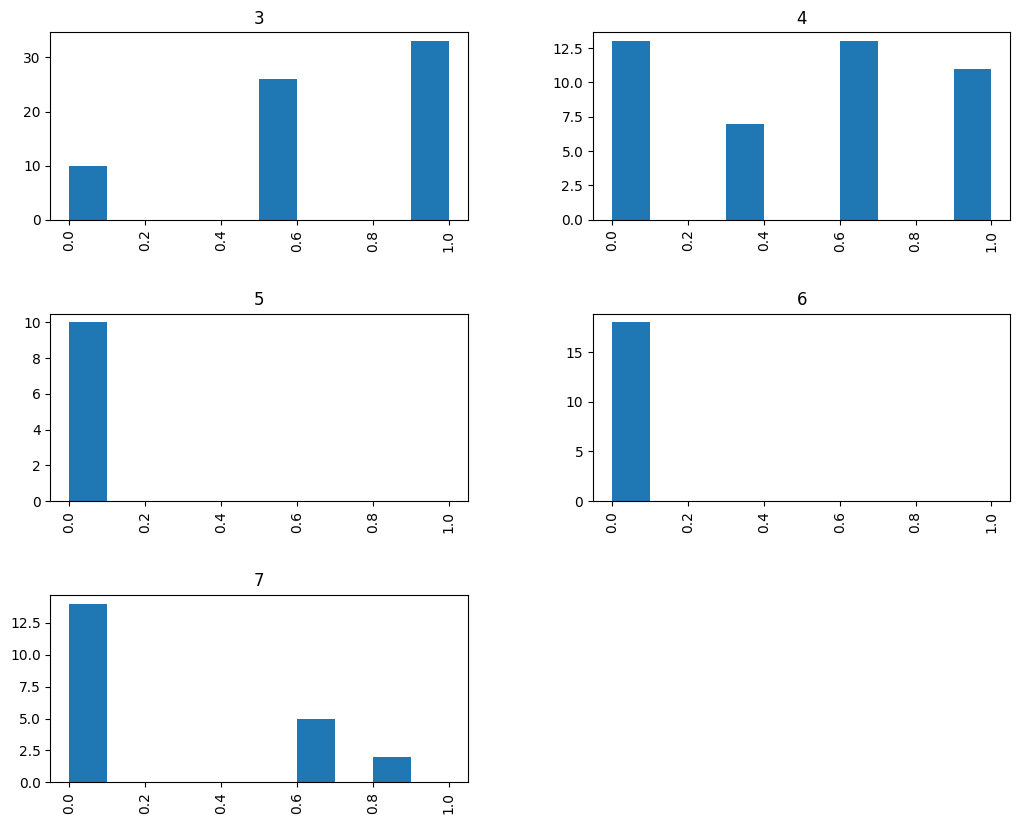

In [28]:
_, ax = plt.subplots(figsize=(12, 10))
train.query('Group_Count > 2').Group_Target.hist(ax=ax, by=train['Group_Count'], range=(0, 1))
plt.show()

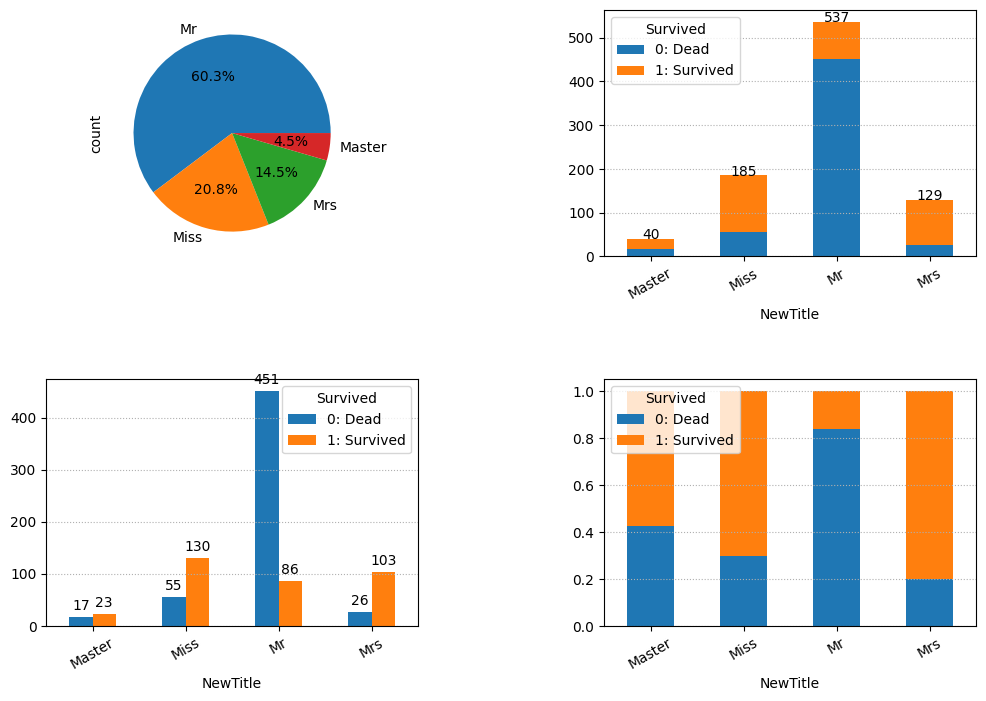

In [29]:
output_bars(train, 'NewTitle')

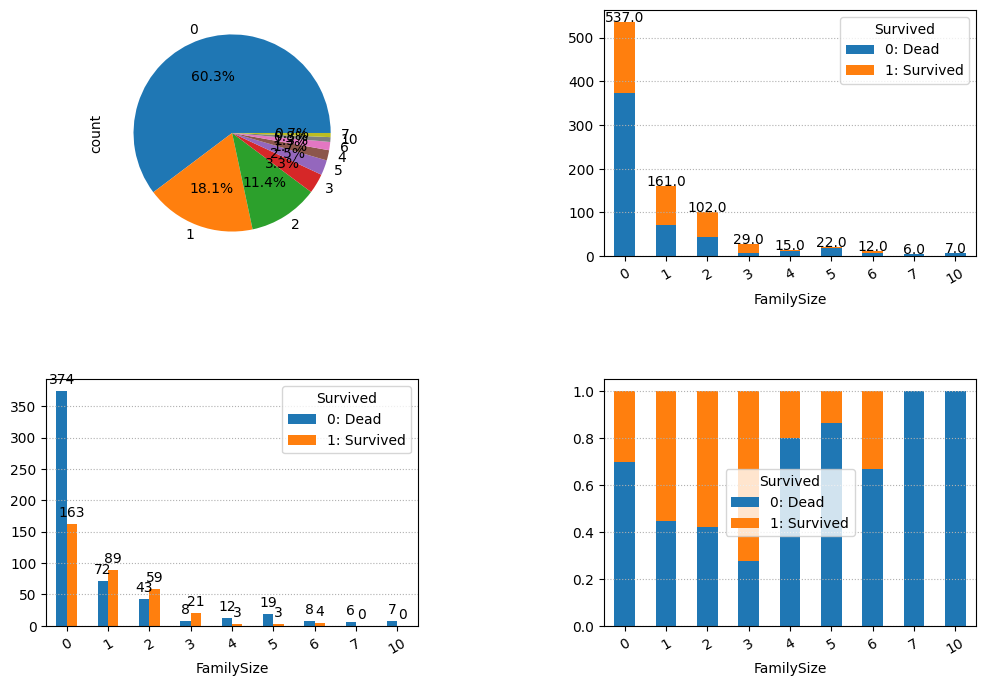

In [30]:
output_bars(train, 'FamilySize')

In [31]:
# 学習曲線出力
def output_learning_curve(ax, x_all, y_all, gscv):
    try:
        training_sizes, train_scores, test_scores = learning_curve(
            gscv.best_estimator_,
            x_all,
            y_all,
            cv=5,
            train_sizes=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            n_jobs=-1,  # 並列処理で高速化
        )
        train_scores_mean = np.mean(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)

        ax.plot(
            training_sizes,
            train_scores_mean,
            "o-",
            color="r",
            label="training scores",
        )
        ax.plot(
            training_sizes,
            test_scores_mean,
            "o-",
            color="g",
            label="test scores",
        )
        ax.set_xlabel("Training instances")
        ax.set_ylabel("Score")
        ax.set_title("Learning Curve")
        ax.legend(loc="best")
        ax.grid(True)
    except Exception as e:
        print(f"Learning curve plot failed: {e}")
        ax.set_title("Learning Curve (Failed)")

In [32]:
# 適合率-再現率グラフ出力
def output_pr_curve(ax, y_test, y_pred):
    # y_pred が 2次元配列 (predict_proba の結果) か 1次元配列かで処理を分ける
    y_scores = y_pred[:, 1] if y_pred.ndim == 2 else y_pred

    # 適合率、再現率、閾値を取得
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

    # 適合率-再現率曲線を描画
    ax.plot(precisions, recalls, label="PR Curve", color="blue", zorder=1)

    # 0から1まで0.05刻みで閾値のポイントをプロット
    for target_thresh in np.linspace(0.0, 1.0, 21):
        # thresholds の中で target_thresh に最も近いインデックスを取得
        close_point = np.argmin(np.abs(thresholds - target_thresh))

        # インデックス範囲外（IndexError）を防ぐため安全に参照
        idx = min(close_point, len(precisions) - 1)
        ax.plot(
            precisions[idx],
            recalls[idx],
            "o",
            color="red",
            markersize=5,
            zorder=2,
        )

    ax.set_xlabel("Precision")
    ax.set_ylabel("Recall")
    ax.set_xlim([0.0, 1.05])
    ax.set_ylim([0.0, 1.05])
    ax.set_title("Precision Recall Curve")
    ax.grid(True)

In [33]:
# グラフまとめ出力関数
def output_graphs(gscv, X, y, X_test):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    # 1. 混同行列
    ConfusionMatrixDisplay.from_estimator(
        gscv.best_estimator_,
        X,
        y,
        ax=axes[0, 0],
        display_labels=['0: Dead', '1: Survived'],
    )
    axes[0, 0].set_title('Confusion Matrix')

    # 2. Grid Search の結果出力 (上位10件)
    result = pd.DataFrame(gscv.cv_results_).set_index('params')
    top10 = result.sort_values('rank_test_score', ascending=True).head(10)
    top10['mean_test_score'].sort_values(ascending=True).plot.barh(
        ax=axes[0, 1], grid=True
    )
    axes[0, 1].set_xlim(
        result['mean_test_score'].min() * 0.9,
        result['mean_test_score'].max() * 1.05,
    )
    axes[0, 1].set_title('GridSearch Top 10 Scores')

    # 3. Feature Importance / Coef 出力 (上位10件)
    axes[0, 2].set_title('Feature Importance / Coef Top 10')
    if hasattr(gscv.best_estimator_, 'feature_importances_'):
        importances = pd.DataFrame(
            {'Importance': gscv.best_estimator_.feature_importances_},
            index=X_test.columns,
        )
        importances.sort_values('Importance', ascending=False).head(
            10
        ).sort_values('Importance', ascending=True).plot.barh(
            ax=axes[0, 2], grid=True
        )
    elif hasattr(gscv.best_estimator_, 'coef_'):
        importances = pd.DataFrame(
            {'Coef': gscv.best_estimator_.coef_[0]}, index=X_test.columns
        )
        importances.sort_values('Coef', ascending=False).head(10).sort_values(
            'Coef', ascending=True
        ).plot.barh(ax=axes[0, 2], grid=True)

    # 4. ROC 曲線出力
    RocCurveDisplay.from_estimator(gscv.best_estimator_, X, y, ax=axes[1, 0])
    axes[1, 0].set_title('ROC Curve')

    # 5. 適合率-再現率グラフ出力
    y_pred = gscv.best_estimator_.predict_proba(X)
    output_pr_curve(axes[1, 1], y, y_pred)

    # 6. 学習曲線出力
    output_learning_curve(axes[1, 2], X, y, gscv)

    plt.tight_layout()
    plt.show()

In [34]:
# 学習と検証の実行関数
def fit(classifier, parameters, X, y, X_test):
    # GridSearchCV の定義（n_jobs=-1 で並列高速化）
    gscv = GridSearchCV(classifier, parameters, cv=5, n_jobs=-1)
    gscv.fit(X, y)

    print('Grid Search Best parameters:', gscv.best_params_)
    print('Grid Search Best validation score:', gscv.best_score_)
    print(
        'Grid Search Best training score:', gscv.best_estimator_.score(X, y)
    )

    # テストデータに対する予測
    predictions = gscv.best_estimator_.predict(X_test)

    # 訓練データに対する予測と評価レポートの表示
    X_pred = gscv.best_estimator_.predict(X)
    print('\nClassification Report (Train Data):')
    print(classification_report(y, X_pred))

    # グラフの集約表示（y を含めた正しい引数で呼び出し）
    output_graphs(gscv, X, y, X_test)

    return gscv, predictions

In [35]:
# 1. OneHotEncoderで生成された列名に合わせる
# (もし OneHotEncoder(feature_name_combiner=...) 等でデフォルトの prefix 'x0_', 'x1_' を維持している場合は元のままで構いません)
features = [
    "Group_Count",
    "Group_Target",
    "PclassEncoded",
    "SexEncoded",
    "Age",
    "FamilySize",
    "Embarked_Q",  # 'x0_Q' から変更（※環境に合わせて 'x0_Q' のままにも対応）
    "Embarked_S",  # 'x0_S' から変更
    "NewTitle_Miss",  # 'x1_Miss' から変更
    "NewTitle_Mr",  # 'x1_Mr' から変更
    "NewTitle_Mrs",  # 'x1_Mrs' から変更
]

# 2. 指定した列が train / test に存在するか事前に確認（エラー未然防止）
missing_train = [col for col in features if col not in train.columns]
missing_test = [col for col in features if col not in test.columns]

if missing_train or missing_test:
    print(f"警告: 以下の列が存在しません。")
    if missing_train:
        print(f"train に無い列: {missing_train}")
    if missing_test:
        print(f"test に無い列: {missing_test}")
else:
    # 3. データの切り出しと型変換
    y = train["Survived"].astype(int)
    tmp_sr = test["PassengerId"]

    X = train[features]
    X_test = test[features]

    # 確認用表示
    print("データ切り出し成功:")
    print(f"X shape: {X.shape}")
    print(f"X_test shape: {X_test.shape}")

データ切り出し成功:
X shape: (891, 11)
X_test shape: (418, 11)


## RandomForestによる学習・予測


Grid Search Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 0}
Grid Search Best validation score: 0.8585525076894106
Grid Search Best training score: 0.867564534231201

Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       549
           1       0.88      0.75      0.81       342

    accuracy                           0.87       891
   macro avg       0.87      0.85      0.86       891
weighted avg       0.87      0.87      0.87       891



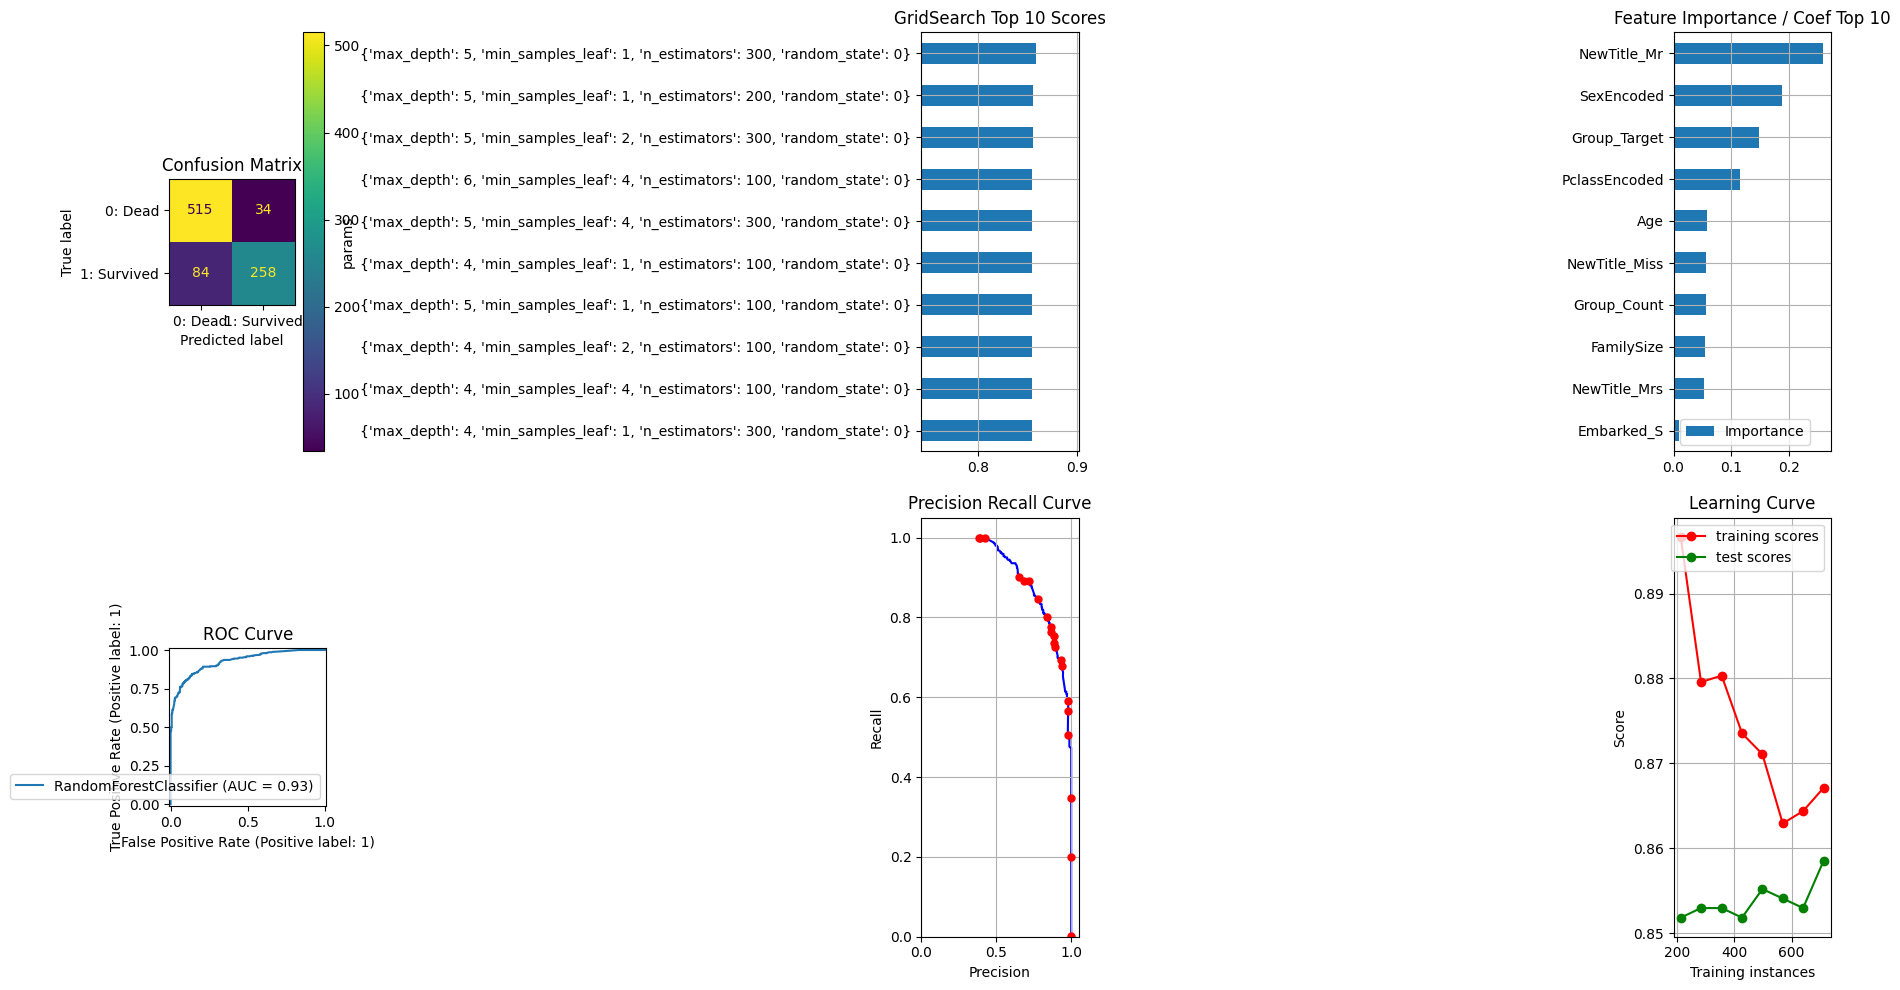

In [36]:
# RandomForestのハイパーパラメータ候補
rf_parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [0],
}

# Cell33で定義したfit関数(GridSearchCV + 各種評価グラフ出力)を利用
rf_gscv, rf_predictions = fit(
    RandomForestClassifier(), rf_parameters, X, y, X_test
)


## 提出用CSVの作成


In [37]:
# 提出用CSVの作成
submission = pd.DataFrame({
    'PassengerId': tmp_sr,
    'Survived': rf_predictions
})
submission.to_csv('submission.csv', index=False)
submission.head()


,PassengerId,Survived
891,892,0
892,893,1
893,894,0
894,895,0
895,896,1
